# Systematic Multi-Asset Alpha Engine

**Research question:** Does integrating ML return forecasts into a Black-Litterman framework improve risk-adjusted performance vs. equal-weight and standard Markowitz?

**Architecture:**
```
Data → Features (walk-forward, no leakage) → ML Ensemble (stacked, OOF-calibrated)
     → GJR-GARCH (volatility + regime) → Black-Litterman (posterior) → CVXPY (MV / Min-CVaR)
     → Backtest (realistic costs) → Statistical Validation
```

**Universe:** 17 assets (equities, sectors, fixed income, commodities)  
**Period:** 2020-01-01 – 2024-12-31 | **Rebalance:** Monthly | **Train window:** 504 days

---
**Key fixes applied:**
- `[WF-1]` Feature engineering moved inside walk-forward loop with `cutoff_date` to prevent look-ahead bias
- `[BL-1]` `τ = 1/T` (observations), not `1/n_assets` — corrects the BL prior scaling by ~14×
- `[ML-1]` Meta-learner refitted on full-data base predictions for calibration consistency
- `[BT-1]` Rebalance dates derived from actual price index (handles holiday-adjusted calendars)
- `[CF-1]` Cornish-Fisher VaR returns `None` when `cf_z ≥ 0` instead of silently taking `abs()`

## 1 · Imports

In [1]:
import sys, warnings, logging
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="arch")

import numpy as np
import pandas as pd
import yfinance as yf
import cvxpy as cp
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from typing import Dict, List, Optional, Tuple
from scipy import stats
from scipy.optimize import minimize
from arch import arch_model
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score
from sklearn.covariance import LedoitWolf

SEED = 42
np.random.seed(SEED)
plt.style.use("seaborn-v0_8-darkgrid")
logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s", datefmt="%H:%M:%S")
log = logging.getLogger("AlphaEngine")

## 2 · Data Engine

In [2]:
class DataEngine:
    """Fetches prices, macro proxies, market caps, and engineers features."""

    def __init__(self, start_date: str, end_date: str):
        self.start_date = start_date
        self.end_date   = end_date
        self.data: Dict = {}

    @staticmethod
    def _extract_close(raw: pd.DataFrame, ticker: str) -> Optional[pd.Series]:
        """Robustly extract Close prices from yfinance's flat or MultiIndex columns."""
        if raw is None or raw.empty:
            return None
        cols = raw.columns
        if isinstance(cols, pd.MultiIndex):
            s = raw.get(("Close", ticker), raw["Close"].iloc[:, 0] if "Close" in cols.get_level_values(0) else None)
        else:
            s = raw.get("Close") or raw.get("Adj Close") or raw.iloc[:, 0]
        s = s.squeeze() if isinstance(s, pd.DataFrame) else s
        return s if isinstance(s, pd.Series) and not s.empty else None

    def fetch_universe(self, tickers: List[str]) -> pd.DataFrame:
        """Per-ticker download for reliability; ffill(limit=5) handles short holiday gaps."""
        log.info(f"Fetching {len(tickers)} assets...")
        prices = {}
        for t in tickers:
            try:
                raw = yf.download(t, start=self.start_date, end=self.end_date, progress=False, auto_adjust=True)
                s = self._extract_close(raw, t)
                if s is not None:
                    prices[t] = s
                    log.info(f"  ✓ {t}: {s.notna().sum()} obs")
                else:
                    log.warning(f"  ✗ {t}: no data")
            except Exception as e:
                log.warning(f"  ✗ {t}: {e}")
        if not prices:
            raise RuntimeError("No price data fetched")
        df = pd.DataFrame(prices).dropna(how="all").ffill(limit=5)
        self.data["prices"] = df
        return df

    def fetch_market_caps(self, tickers: List[str]) -> pd.Series:
        """Market cap / AUM as BL prior weights; fallback to equal weights."""
        caps = {}
        for t in tickers:
            try:
                info = yf.Ticker(t).fast_info
                mc = getattr(info, "market_cap", None)
                if mc is None or np.isnan(float(mc)):
                    lp, sh = getattr(info, "last_price", None), getattr(info, "shares", None)
                    mc = lp * sh if lp and sh else None
                if mc:
                    caps[t] = float(mc)
            except Exception:
                pass
        if not caps:
            return pd.Series(1.0, index=tickers)
        s = pd.Series(caps)
        return s.reindex(tickers).fillna(s.median())

    def engineer_features(self, cutoff_date: Optional[str] = None) -> Dict[str, pd.DataFrame]:
        """
        Multi-factor feature set per asset.
        [WF-1] cutoff_date ensures no look-ahead when called inside the walk-forward loop.

        Features: momentum (5/21/63/252d), realised vol, SMA ratios,
                  MACD, Bollinger width, Wilder RSI, rolling moments.
        """
        prices = self.data["prices"]
        if cutoff_date:
            prices = prices.loc[:cutoff_date]
        returns = prices.pct_change()
        features = {}

        for t in prices.columns:
            p, r = prices[t], returns[t]
            f = pd.DataFrame(index=prices.index)
            f["price"]     = p
            f["return_1d"] = r

            for period in [5, 21, 63, 252]:
                f[f"mom_{period}d"] = p.pct_change(period)
                f[f"vol_{period}d"] = r.rolling(period).std() * np.sqrt(252)

            sma20 = p.rolling(20).mean()
            sma50 = p.rolling(50).mean()
            f["price_to_sma20"] = p / sma20 - 1
            f["sma20_to_sma50"] = sma20 / sma50 - 1

            ema12, ema26 = p.ewm(span=12, adjust=False).mean(), p.ewm(span=26, adjust=False).mean()
            macd = ema12 - ema26
            f["macd"]      = macd
            f["macd_hist"] = macd - macd.ewm(span=9, adjust=False).mean()
            f["bb_width"]  = 2 * r.rolling(20).std() / (sma20 / p)

            # Wilder RSI (com=13 ≡ span=27, matching Wilder's smoothing)
            gain = r.where(r > 0, 0.0).ewm(com=13, adjust=False).mean()
            loss = (-r.where(r < 0, 0.0)).ewm(com=13, adjust=False).mean()
            f["rsi"] = 100 - (100 / (1 + gain / loss.replace(0, np.nan)))

            f["ret_mean_63d"] = r.rolling(63).mean()
            f["ret_skew_63d"] = r.rolling(63).skew()
            f["ret_kurt_63d"] = r.rolling(63).kurt()

            features[t] = f

        self.data["features"] = features
        return features

## 3 · ML Alpha Engine

In [3]:
class MLAlphaEngine:
    """
    Stacked ensemble (RF + GBM + SVR + Ridge) for cross-sectional return forecasting.

    Two-stage training [ML-1]:
      Stage 1: Walk-forward OOF predictions → fit meta-learner → unbiased performance
      Stage 2: Full refit of base models + meta-learner on same data → calibration-consistent inference
    """

    def __init__(self):
        self.models: Dict          = {}
        self.scalers: Dict         = {}
        self.feat_importance: Dict = {}

    def prepare_data(self, features: pd.DataFrame, horizon: int = 5) -> Tuple[pd.DataFrame, pd.Series]:
        """Compound forward return target avoids sign-flip artifacts from pct_change composition."""
        p = features["price"]
        y = (p.shift(-horizon) / p - 1).rename("fwd_return")
        X = features.drop(columns=["return_1d", "price"], errors="ignore")
        valid = X.notna().all(axis=1) & y.notna()
        return X[valid], y[valid]

    @staticmethod
    def _ic(actuals: np.ndarray, preds: np.ndarray) -> float:
        """Spearman IC — industry-standard alpha quality metric."""
        return float(stats.spearmanr(actuals, preds).statistic)

    def train(self, X: pd.DataFrame, y: pd.Series, ticker: str) -> Dict:
        """
        Walk-forward CV with per-fold scaling (no look-ahead).
        Returns OOF performance metrics (unbiased); stores full-data models for inference.
        """
        n = len(X)
        tscv = TimeSeriesSplit(n_splits=5)

        base_models = [
            ("rf",  RandomForestRegressor(n_estimators=200, max_depth=8, min_samples_split=15, max_features=0.5, random_state=SEED, n_jobs=-1)),
            ("gbr", GradientBoostingRegressor(n_estimators=150, max_depth=4, learning_rate=0.05, subsample=0.8, random_state=SEED)),
            ("svr", SVR(kernel="rbf", C=0.5, epsilon=0.05, gamma="scale")),
            ("ridge", Ridge(alpha=1.0)),
        ]

        oof = {name: np.full(n, np.nan) for name, _ in base_models}
        actuals = np.full(n, np.nan)

        # Stage 1: OOF walk-forward CV
        for train_idx, test_idx in tscv.split(X):
            scaler = StandardScaler()
            Xtr_s = scaler.fit_transform(X.iloc[train_idx])
            Xte_s = scaler.transform(X.iloc[test_idx])
            for name, m in base_models:
                m.fit(Xtr_s, y.iloc[train_idx])
                oof[name][test_idx] = m.predict(Xte_s)
            actuals[test_idx] = y.iloc[test_idx].values

        valid = ~np.isnan(actuals)
        meta_X_oof = np.column_stack([oof[n][valid] for n, _ in base_models])
        meta_y_oof = actuals[valid]

        meta_scaler_oof = StandardScaler()
        meta_oof = Ridge(alpha=0.5)
        meta_oof.fit(meta_scaler_oof.fit_transform(meta_X_oof), meta_y_oof)
        oof_preds = meta_oof.predict(meta_scaler_oof.transform(meta_X_oof))

        oof_ic   = self._ic(meta_y_oof, oof_preds)
        oof_r2   = r2_score(meta_y_oof, oof_preds)
        cal_slope = float(np.polyfit(meta_y_oof, oof_preds, 1)[0])

        # Stage 2: Full refit — base models and meta-learner on same data [ML-1]
        final_scaler = StandardScaler()
        Xall_s = final_scaler.fit_transform(X)
        for name, m in base_models:
            m.fit(Xall_s, y)

        full_base = np.column_stack([m.predict(Xall_s) for _, m in base_models])
        meta_scaler_final = StandardScaler()
        meta_final = Ridge(alpha=0.5)
        meta_final.fit(meta_scaler_final.fit_transform(full_base), y.values)

        self.models[ticker]  = {name: m for name, m in base_models}
        self.models[ticker].update({"meta": meta_final, "meta_scaler": meta_scaler_final})
        self.scalers[ticker] = final_scaler
        self.feat_importance[ticker] = pd.Series(
            dict(zip(X.columns, base_models[0][1].feature_importances_))
        ).sort_values(ascending=False)

        log.info(f"  {ticker}: OOF IC={oof_ic:.4f}  R²={oof_r2:.4f}  CalSlope={cal_slope:.3f}")
        return {"IC": oof_ic, "r2": oof_r2, "calibration_slope": cal_slope}

    def predict(self, X: pd.DataFrame, ticker: str) -> np.ndarray:
        m = self.models[ticker]
        Xs = self.scalers[ticker].transform(X)
        base = np.column_stack([m[name].predict(Xs) for name in ["rf", "gbr", "svr", "ridge"]])
        return m["meta"].predict(m["meta_scaler"].transform(base))

## 4 · Volatility Engine (GJR-GARCH)

In [4]:
class VolatilityEngine:
    """
    GJR-GARCH(1,1,1) with skewed-t errors.

    σ²_t = ω + (α + γ·I[ε_{t-1}<0])·ε²_{t-1} + β·σ²_{t-1}
    γ > 0 captures leverage effect: equity vol rises more on negative shocks.
    """

    def __init__(self):
        self.models:    Dict = {}
        self.forecasts: Dict = {}
        self._hist_vol: Dict = {}

    def fit(self, returns: pd.Series, ticker: str) -> Optional[Dict]:
        """Fit GJR-GARCH-skewt; returns parameter dict or None on failure."""
        try:
            res = arch_model(returns.dropna() * 100, vol="GARCH", p=1, o=1, q=1,
                             dist="skewt", rescale=False).fit(disp="off", show_warning=False)
            self.models[ticker]   = res
            self._hist_vol[ticker] = np.sqrt(res.conditional_volatility) / 100 * np.sqrt(252)

            a = res.params.get("alpha[1]", np.nan)
            g = res.params.get("gamma[1]", np.nan)
            b = res.params.get("beta[1]",  np.nan)
            o = res.params.get("omega",    np.nan)
            persist = a + 0.5 * g + b if not any(np.isnan(v) for v in [a, g, b]) else np.nan
            lr_vol  = (np.sqrt(o / max(1 - persist, 1e-6)) / 100 * np.sqrt(252)
                       if not np.isnan(persist) else np.nan)

            params = {"alpha": a, "gamma": g, "beta": b, "omega": o,
                      "persistence": persist, "long_run_vol_ann": lr_vol}
            log.info(f"  {ticker}: α={a:.4f} γ={g:.4f} β={b:.4f} persist={persist:.4f} LR_vol={lr_vol:.2%}")
            return params
        except Exception as e:
            log.error(f"  GARCH failed {ticker}: {e}")
            return None

    def forecast(self, ticker: str, horizon: int = 5) -> np.ndarray:
        """Return annualised conditional vol forecast for next `horizon` days."""
        fc = self.models[ticker].forecast(horizon=horizon, reindex=False)
        vol_ann = np.sqrt(fc.variance.values[-1]) / 100 * np.sqrt(252)
        self.forecasts[ticker] = vol_ann
        return vol_ann

    def regime(self, ticker: str, pct: float = 75) -> str:
        """Per-asset regime: high_vol if current forecast > pth percentile of history."""
        hist      = self._hist_vol[ticker]
        threshold = np.percentile(hist[~np.isnan(hist)], pct)
        current   = float(np.mean(self.forecasts[ticker]))
        return "high_vol" if current > threshold else "low_vol"

## 5 · Black-Litterman Optimizer

In [5]:
class BlackLittermanOptimizer:
    """
    Bayesian portfolio construction with Ledoit-Wolf shrinkage.

    τ = 1/T  (Idzorek: scales with estimation uncertainty in the prior)
    Ω = (1/c - 1)·τ·P·Σ·Pᵀ  (He & Litterman proportional uncertainty)
    Posterior: μ_BL = [(τΣ)⁻¹ + PᵀΩ⁻¹P]⁻¹ · [(τΣ)⁻¹Π + PᵀΩ⁻¹Q]
    """

    def __init__(self, risk_free_rate: float = 0.04, risk_aversion: float = 2.5):
        self.rf  = risk_free_rate
        self.lam = risk_aversion

    def _cov(self, returns: pd.DataFrame) -> pd.DataFrame:
        """Ledoit-Wolf shrinkage covariance (annualised)."""
        lw = LedoitWolf().fit(returns.dropna())
        return pd.DataFrame(lw.covariance_ * 252, index=returns.columns, columns=returns.columns)

    def equilibrium(self, returns: pd.DataFrame, market_caps: pd.Series) -> Tuple[pd.Series, pd.DataFrame]:
        """Reverse-optimisation prior: Π = δ·Σ·w_mkt."""
        cov   = self._cov(returns)
        w_mkt = market_caps.reindex(cov.index).fillna(market_caps.median())
        w_mkt /= w_mkt.sum()
        return self.lam * cov.dot(w_mkt), cov

    def posterior(self, eq_ret: pd.Series, cov: pd.DataFrame,
                  views: Dict[str, float], confidence: float = 0.5, n_obs: int = 252) -> pd.Series:
        """
        Compute BL posterior expected returns.
        [BL-1] τ = 1/n_obs (observation count), not n_assets.
        """
        n_assets, n_views = len(eq_ret), len(views)
        tau = 1.0 / max(n_obs, 1)

        P = np.zeros((n_views, n_assets))
        Q = np.zeros(n_views)
        for i, (t, v) in enumerate(views.items()):
            if t in eq_ret.index:
                P[i, eq_ret.index.get_loc(t)] = 1.0
                Q[i] = v

        # He & Litterman: Ω proportional to view portfolio variance
        Omega = (1.0 / max(confidence, 1e-4) - 1.0) * tau * (P @ cov.values @ P.T) + np.eye(n_views) * 1e-8
        tau_sig_inv = np.linalg.inv(tau * cov.values + np.eye(n_assets) * 1e-8)
        try:
            Omega_inv = np.linalg.inv(Omega)
        except np.linalg.LinAlgError:
            Omega_inv = np.linalg.pinv(Omega)

        M   = tau_sig_inv + P.T @ Omega_inv @ P
        rhs = tau_sig_inv @ eq_ret.values + P.T @ Omega_inv @ Q
        try:
            post = np.linalg.solve(M, rhs)
        except np.linalg.LinAlgError:
            post = np.linalg.lstsq(M, rhs, rcond=None)[0]
        return pd.Series(post, index=eq_ret.index)

    def optimize_mv(self, mu: pd.Series, cov: pd.DataFrame,
                    max_weight: float = 0.30, regime: str = "low_vol") -> pd.Series:
        """
        Mean-variance QP via CVXPY.
        Regime-aware risk aversion: 2× penalty in high-vol regimes.
        Solver cascade: CLARABEL → OSQP → ECOS.
        """
        lam = self.lam * (2.0 if regime == "high_vol" else 1.0)
        n, w = len(mu), cp.Variable(len(mu))
        prob = cp.Problem(
            cp.Maximize(mu.values @ w - (lam / 2) * cp.quad_form(w, cov.values)),
            [cp.sum(w) == 1, w >= 0, w <= max_weight]
        )
        for solver in [cp.CLARABEL, cp.OSQP, cp.ECOS]:
            try:
                prob.solve(solver=solver, verbose=False)
                if w.value is not None:
                    wts = pd.Series(np.clip(w.value, 0, max_weight), index=mu.index)
                    return wts / wts.sum()
            except Exception:
                continue
        log.warning("MV optimization failed — equal weights")
        return pd.Series(1 / n, index=mu.index)

    def optimize_min_cvar(self, returns: pd.DataFrame, alpha: float = 0.05,
                          max_weight: float = 0.30) -> pd.Series:
        """
        Min-CVaR portfolio via LP — more robust than MV under non-normal returns.
        Used in high-vol regimes where tail risk matters more than variance.
        """
        T, n = returns.shape
        w, eta, z = cp.Variable(n), cp.Variable(), cp.Variable(T)
        prob = cp.Problem(
            cp.Minimize(eta + (1 / (alpha * T)) * cp.sum(z)),
            [z >= 0, z >= -(returns.values @ w) - eta, cp.sum(w) == 1, w >= 0, w <= max_weight]
        )
        for solver in [cp.CLARABEL, cp.ECOS, cp.SCS]:
            try:
                prob.solve(solver=solver, verbose=False)
                if w.value is not None:
                    wts = pd.Series(np.clip(w.value, 0, max_weight), index=returns.columns)
                    return wts / wts.sum()
            except Exception:
                continue
        log.warning("Min-CVaR failed — equal weights")
        return pd.Series(1 / n, index=returns.columns)

    def optimize_risk_parity(self, cov: pd.DataFrame) -> pd.Series:
        """Equal Risk Contribution — return-free, more robust out-of-sample."""
        n, Sig = len(cov), cov.values
        def objective(w):
            vol = np.sqrt(w @ Sig @ w)
            rc  = w * (Sig @ w) / vol
            return np.sum((rc - vol / n) ** 2)
        res = minimize(objective, np.ones(n) / n, method="SLSQP",
                       bounds=[(0.01, 0.30)] * n,
                       constraints=[{"type": "eq", "fun": lambda w: w.sum() - 1}],
                       options={"ftol": 1e-12, "maxiter": 500})
        if res.success:
            wts = pd.Series(res.x, index=cov.index)
            return wts / wts.sum()
        return pd.Series(1 / n, index=cov.index)

## 6 · Backtest Engine

In [6]:
class PortfolioBacktester:
    """
    Event-driven backtester with realistic cost model.
    Commission: 5 bps | Bid-ask: 3–10 bps (per-ticker, based on liquidity).
    """

    BID_ASK = {"SPY": 3e-4, "QQQ": 3e-4, "IWM": 5e-4, "EFA": 5e-4, "EEM": 8e-4,
               "TLT": 4e-4, "IEF": 4e-4, "LQD": 6e-4, "GLD": 4e-4, "USO": 1e-3}
    COMMISSION = 5e-4

    def __init__(self, initial_capital: float = 1_000_000, risk_free_rate: float = 0.04):
        self.initial_capital  = initial_capital
        self.rf_daily         = risk_free_rate / 252
        self.portfolio_history = pd.DataFrame()

    def _tcost(self, ticker: str, notional: float) -> float:
        return notional * (self.BID_ASK.get(ticker, 8e-4) / 2 + self.COMMISSION)

    @staticmethod
    def _rebalance_dates(index: pd.DatetimeIndex, freq: str = "ME") -> set:
        """
        [BT-1] Derive rebalance dates from actual price index (not synthetic date_range).
        Resample the index itself so month-ends align to the last actual trading day.
        """
        s = pd.Series(index, index=index)
        try:
            return set(s.resample(freq).last().dropna())
        except Exception:
            return set(s.resample("ME").last().dropna())

    def run(self, prices: pd.DataFrame, weights_history: pd.DataFrame,
            freq: str = "ME") -> pd.DataFrame:
        holdings = pd.Series(0.0, index=prices.columns)
        cash     = float(self.initial_capital)
        results  = []

        common     = prices.index.intersection(weights_history.index)
        reb_dates  = self._rebalance_dates(common, freq)

        log.info(f"Backtest: {common[0].date()} → {common[-1].date()} | {len(reb_dates)} rebalances")

        for date in common:
            px   = prices.loc[date]
            pv   = float((holdings * px).sum()) + cash

            if date in reb_dates:
                tgt = weights_history.loc[date].reindex(prices.columns).fillna(0)
                tgt /= tgt.sum()
                tgt_holdings = tgt * pv / px.replace(0, np.nan)
                delta  = (tgt_holdings - holdings).dropna()
                tcosts = sum(self._tcost(t, abs(d) * px.get(t, 0)) for t, d in delta.items())
                cash   = pv - float((tgt_holdings * px).sum()) - tcosts
                holdings = tgt_holdings.fillna(0)

            results.append({"date": date, "portfolio_value": pv, "cash": cash})

        self.portfolio_history = pd.DataFrame(results).set_index("date")
        return self.portfolio_history

    def metrics(self, benchmark: Optional[pd.Series] = None) -> Dict:
        ph      = self.portfolio_history
        ret     = ph["portfolio_value"].pct_change().dropna()
        excess  = ret - self.rf_daily
        ann_ret = float(ret.mean() * 252)
        ann_vol = float(ret.std() * np.sqrt(252))
        sharpe  = float(excess.mean() * 252 / (excess.std() * np.sqrt(252)))

        cum = (1 + ret).cumprod()
        mdd = float(((cum - cum.expanding().max()) / cum.expanding().max()).min())

        # Sortino: downside deviation only
        downside = excess[excess < 0]
        sortino  = float(excess.mean() * 252 / (downside.std() * np.sqrt(252))) if len(downside) > 1 else np.nan

        result = {"Ann. Return": f"{ann_ret:.2%}", "Ann. Volatility": f"{ann_vol:.2%}",
                  "Sharpe Ratio": f"{sharpe:.3f}", "Sortino Ratio": f"{sortino:.3f}",
                  "Max Drawdown": f"{mdd:.2%}"}

        if benchmark is not None:
            b = benchmark.reindex(ret.index).dropna()
            beta   = float(np.cov(ret.reindex(b.index), b)[0, 1] / b.var())
            alpha  = float(ann_ret - beta * b.mean() * 252)
            result.update({"Beta": f"{beta:.3f}", "Alpha (ann.)": f"{alpha:.2%}"})

        return result

## 7 · Statistical Validation

In [15]:
class StatisticalTests:
    """
    Three significance tests for backtest validation:
    1. Block-bootstrap Sharpe p-value  — accounts for return autocorrelation
    2. Deflated Sharpe Ratio (Harvey & Liu 2015) — penalises multiple testing
    3. IC t-test — confirms ML signal has non-zero predictive content
    """

    @staticmethod
    def block_bootstrap_sharpe(
        returns: pd.Series,
        n_bootstrap: int = 5000,
        block_size: int = 21,
        rf: float = 0.04,
    ) -> Dict:
        """
        Circular block bootstrap p-value for H₀: SR = 0.
        block_size=21 ≈ 1 trading month; preserves autocorrelation structure.
        """
        ex  = (returns.dropna() - rf / 252).values
        n   = len(ex)
        obs_sr = float(np.sqrt(252) * ex.mean() / ex.std())
        rng = np.random.default_rng(SEED)
        null_srs = []
        for _ in range(n_bootstrap):
            starts  = rng.integers(0, n, size=n // block_size + 1)
            idx     = np.concatenate([np.arange(s, s + block_size) % n for s in starts])[:n]
            boot    = ex[idx]
            boot    = boot - boot.mean()   # centre under H₀: SR = 0
            null_srs.append(np.sqrt(252) * boot.mean() / (boot.std() + 1e-10))
        p = float(np.mean(np.array(null_srs) >= obs_sr))
        return {"observed_sr": obs_sr, "p_value": p, "significant_5pct": p < 0.05}

    @staticmethod
    def deflated_sharpe_ratio(
        observed_sharpe: float,
        n_trials: int,
        n_obs: int,
        skewness: float = 0.0,
        excess_kurtosis: float = 0.0,
    ) -> Dict:
        """DSR > 1 means Sharpe survives multiple-testing penalty."""
        g = 0.5772  # Euler-Mascheroni constant
        E_max = (
            (1 - g) * stats.norm.ppf(1 - 1 / n_trials) +
            g       * stats.norm.ppf(1 - 1 / (n_trials * np.e))
        ) if n_trials > 1 else 0.0
        thr_ann = (
            E_max / np.sqrt(n_obs)
            * np.sqrt(1 - skewness * observed_sharpe + (excess_kurtosis - 1) / 4 * observed_sharpe**2)
            * np.sqrt(252)
        )
        dsr = observed_sharpe / max(thr_ann, 1e-10)
        return {"DSR": dsr, "sr_threshold_ann": thr_ann, "passes_dsr": dsr > 1.0}

    @staticmethod
    def ic_significance(ic_series: pd.Series) -> Dict:
        """One-sample t-test on IC time series (H₀: mean IC = 0). ICIR = mean/std."""
        ic = ic_series.dropna()
        if len(ic) < 5:
            return {"error": "Insufficient observations"}
        t, p = stats.ttest_1samp(ic, popmean=0.0)
        icir = float(ic.mean() / ic.std()) if ic.std() > 0 else np.nan
        return {
            "mean_IC": float(ic.mean()), "ICIR": icir,
            "t_stat": float(t), "p_value": float(p),
            "significant_5pct": p < 0.05,
        }

    @classmethod
    def report(cls, portfolio_history: pd.DataFrame, all_ml_metrics: Dict,
               n_trials: int = 10, rf: float = 0.04) -> None:
        ret = portfolio_history["portfolio_value"].pct_change().dropna()
        print("\n" + "="*55 + "\n  STATISTICAL SIGNIFICANCE REPORT\n" + "="*55)

        bbs = cls.block_bootstrap_sharpe(ret, rf=rf)
        print(f"\n[1] Block-Bootstrap Sharpe (H₀: SR=0, B=5000, block=21d)")
        print(f"    SR={bbs['observed_sr']:.3f}  p={bbs['p_value']:.4f}  "
              f"{'✓ Significant' if bbs['significant_5pct'] else '✗ Not significant'} at 5%")

        dsr = cls.deflated_sharpe_ratio(
            bbs["observed_sr"], n_trials, len(ret),
            skewness=float(ret.skew()), excess_kurtosis=float(ret.kurt()),
        )
        print(f"\n[2] Deflated Sharpe Ratio (Harvey & Liu 2015, n_trials={n_trials})")
        print(f"    DSR={dsr['DSR']:.3f}  threshold={dsr['sr_threshold_ann']:.3f}  "
              f"{'✓ Passes' if dsr['passes_dsr'] else '✗ Fails'}")

        if all_ml_metrics:
            ic_vals = pd.Series({t: m.get("IC", np.nan) for t, m in all_ml_metrics.items()}).dropna()
            ic_res  = cls.ic_significance(ic_vals)
            if "error" not in ic_res:
                print(f"\n[3] ML Signal IC (H₀: IC=0, n={len(ic_vals)} assets)")
                print(f"    mean_IC={ic_res['mean_IC']:.4f}  ICIR={ic_res['ICIR']:.3f}  "
                      f"p={ic_res['p_value']:.4f}  "
                      f"{'✓ Significant' if ic_res['significant_5pct'] else '✗ Not significant'} at 5%")

        print("="*55)

## 8 · Walk-Forward Orchestration

In [16]:
def run_walk_forward(
    start_date:      str   = "2020-01-01",
    end_date:        str   = "2024-12-31",
    initial_capital: float = 1_000_000,
    train_window:    int   = 504,
    rebalance_freq:  str   = "ME",
    ml_horizon:      int   = 21,
    max_weight:      float = 0.30,
    view_confidence: float = 0.65,
    run_ablation:    bool  = True,
) -> Dict:
    """
    Walk-forward pipeline:
      DataEngine → features (per-rebalance, no leakage) → ML alpha
      → GJR-GARCH (vol + regime) → BL posterior → CVXPY optimize
      → Backtest → StatisticalTests
    """
    UNIVERSE = ["SPY", "QQQ", "IWM", "EFA", "EEM",   # Equities
                "XLF", "XLE", "XLK", "XLV", "XLI",   # Sectors
                "TLT", "IEF", "LQD",                   # Fixed income
                "GLD", "USO"]                           # Commodities

    print(f"\n{'='*70}\n  WALK-FORWARD ALPHA ENGINE\n{'='*70}")
    print(f"Universe: {len(UNIVERSE)} assets | Window: {train_window}d | Freq: {rebalance_freq}")

    # ── Data ────────────────────────────────────────────────────────────
    data_eng    = DataEngine(start_date, end_date)
    prices      = data_eng.fetch_universe(UNIVERSE)
    market_caps = data_eng.fetch_market_caps(UNIVERSE)
    returns     = prices.pct_change().dropna()
    print(f"Loaded: {len(prices)} trading days, {prices.shape[1]} assets")

    # ── Rebalance schedule (aligned to actual trading days) ─────────────
    reb_raw   = pd.date_range(prices.index[train_window], prices.index[-1], freq=rebalance_freq)
    reb_dates = pd.DatetimeIndex(sorted(set(
        prices.index[min(prices.index.searchsorted(d), len(prices) - 1)]
        for d in reb_raw
        if prices.index.searchsorted(d) >= train_window
    )))
    print(f"Rebalance schedule: {len(reb_dates)} periods")

    # ── Walk-forward loop ────────────────────────────────────────────────
    weights_record  = {}
    ablation_record = {}
    ml_metrics_all  = {}
    ic_history      = {t: [] for t in UNIVERSE}

    for i, reb_date in enumerate(reb_dates):
        loc       = prices.index.get_loc(reb_date)
        start_loc = max(0, loc - train_window)

        train_prices  = prices.iloc[start_loc:loc]
        train_returns = returns.iloc[start_loc:loc]
        n_obs         = len(train_returns)

        if n_obs < 252:
            continue

        print(f"  [{i+1}/{len(reb_dates)}] {reb_date.date()} (n={n_obs})", end="  ")

        # Step A: Features — [WF-1] restrict to data available up to reb_date
        data_eng.data["prices"] = train_prices
        feat_dict = data_eng.engineer_features(cutoff_date=str(reb_date.date()))
        data_eng.data["prices"] = prices  # restore

        # Step B: ML alpha — train per asset, collect views where IC > 0
        ml_eng   = MLAlphaEngine()
        ml_views: Dict[str, float] = {}

        for t in UNIVERSE:
            if t not in feat_dict:
                continue
            X, y = ml_eng.prepare_data(feat_dict[t].dropna(), horizon=ml_horizon)
            if len(X) < 100:
                continue
            try:
                m = ml_eng.train(X, y, t)
                ic_history[t].append(m["IC"])
                if m["IC"] > 0:
                    ml_views[t]        = float(ml_eng.predict(X.iloc[-1:], t)[0])
                    ml_metrics_all[t]  = m
            except Exception:
                pass

        # Step C: GJR-GARCH vol forecasts + portfolio regime
        vol_eng = VolatilityEngine()
        regimes: Dict[str, str] = {}

        for t in list(ml_views.keys()):
            if t not in train_returns.columns:
                continue
            try:
                if vol_eng.fit(train_returns[t], t) is None:
                    continue
                vol_eng.forecast(t, horizon=5)
                regimes[t] = vol_eng.regime(t)
            except Exception:
                pass

        portfolio_regime = "high_vol" if sum(r == "high_vol" for r in regimes.values()) > len(regimes) / 2 else "low_vol"

        # Step D: BL optimization (with and without ML views for ablation)
        selected = [t for t in ml_views if t in train_returns.columns]

        def _optimize(use_ml_views: bool) -> pd.Series:
            if len(selected) < 3:
                return pd.Series(1 / len(UNIVERSE), index=UNIVERSE)
            try:
                bl  = BlackLittermanOptimizer(risk_aversion=2.5)
                tr  = train_returns[selected].dropna()
                mc  = market_caps.reindex(selected).fillna(market_caps.median())
                eq, cov = bl.equilibrium(tr, mc)
                mu = bl.posterior(eq, cov, ml_views if use_ml_views else {}, view_confidence, n_obs) if use_ml_views else eq

                wts = (bl.optimize_min_cvar(tr, max_weight=max_weight) if portfolio_regime == "high_vol"
                       else bl.optimize_mv(mu, cov, max_weight=max_weight, regime=portfolio_regime))

                wts = wts.reindex(UNIVERSE).fillna(0)
                return wts / wts.sum() if wts.sum() > 0 else pd.Series(1 / len(UNIVERSE), index=UNIVERSE)
            except Exception as e:
                log.warning(f"Optimization failed: {e} → equal weights")
                return pd.Series(1 / len(UNIVERSE), index=UNIVERSE)

        wts = _optimize(use_ml_views=True)
        weights_record[reb_date] = wts
        if run_ablation:
            ablation_record[reb_date] = _optimize(use_ml_views=False)

        top3 = wts[wts > 0.01].nlargest(3)
        print(f"regime={portfolio_regime}  views={len(ml_views)}  top=[{', '.join(f'{t}:{v:.0%}' for t,v in top3.items())}]")

    if not weights_record:
        raise RuntimeError("No weight snapshots — check data quality")

    def _assemble(record: Dict) -> pd.DataFrame:
        wh  = pd.DataFrame(record).T.reindex(prices.index).ffill()
        eq  = 1 / len(UNIVERSE)
        fvi = wh.first_valid_index()
        if fvi:
            wh.loc[wh.index < fvi] = eq
        return wh.fillna(eq)

    weights_history  = _assemble(weights_record)
    common_tickers   = [t for t in UNIVERSE if t in prices.columns]

    # ── Backtest ─────────────────────────────────────────────────────────
    print("\nRunning backtest...")
    bt  = PortfolioBacktester(initial_capital)
    ph  = bt.run(prices[common_tickers], weights_history[common_tickers], rebalance_freq)
    spy = prices["SPY"].pct_change() if "SPY" in prices.columns else None
    m   = bt.metrics(spy)

    print("\n" + "="*55 + "\n  PERFORMANCE SUMMARY — ML + BL STRATEGY\n" + "="*55)
    for k, v in m.items():
        print(f"  {k:<35} {v}")

    # ── BL-only ablation ─────────────────────────────────────────────────
    ablation_metrics = {}
    if run_ablation and ablation_record:
        abl_wh = _assemble(ablation_record)
        abl_bt = PortfolioBacktester(initial_capital)
        abl_bt.run(prices[common_tickers], abl_wh[common_tickers], rebalance_freq)
        ablation_metrics = abl_bt.metrics(spy)
        print("\n  ABLATION (BL-only, no ML views)")
        for k, v in ablation_metrics.items():
            print(f"  {k:<35} {v:>12}  (full: {m.get(k,'—'):>12})")

    # ── Statistical tests ────────────────────────────────────────────────
    port_rets = ph["portfolio_value"].pct_change().dropna()
    StatisticalTests.report(ph, ml_metrics_all, n_trials=max(len(ml_metrics_all), 1))

    # IC per asset
    print("\n  Per-asset IC significance:")
    for t, ics in ic_history.items():
        if len(ics) >= 5:
            r = StatisticalTests.ic_significance(pd.Series(ics))
            if "error" not in r:
                sig = "✓" if r["significant_5pct"] else "✗"
                print(f"    {t:<6} mean_IC={r['mean_IC']:.3f}  ICIR={r['ICIR']:.2f}  p={r['p_value']:.3f}  {sig}")

    return {"backtester": bt, "metrics": m, "ablation_metrics": ablation_metrics,
            "weights_history": weights_history, "ml_metrics": ml_metrics_all,
            "ic_history": ic_history, "spy_returns": spy,
            "prices": prices, "common_tickers": common_tickers, "port_rets": port_rets}

## 9 · Evaluation & Visualisation

In [17]:
def plot_performance(ph: pd.DataFrame, benchmark: Optional[pd.Series] = None,
                     title: str = "Portfolio Performance") -> None:
    """4-panel performance dashboard: cumulative return, drawdown, rolling Sharpe, return distribution."""
    ret = ph["portfolio_value"].pct_change().dropna()
    rf  = 0.04 / 252

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(title, fontsize=16, fontweight="bold")

    # Cumulative return
    ax = axes[0, 0]
    norm = (1 + ret).cumprod()
    ax.plot(norm.index, norm, label="Strategy", color="#2E86AB", linewidth=2)
    if benchmark is not None:
        b = benchmark.reindex(ret.index).dropna()
        b_norm = (1 + b).cumprod() / (1 + b).cumprod().iloc[0]
        ax.plot(b_norm.index, b_norm, label="SPY", color="#A23B72", linestyle="--", linewidth=2)
    ax.set_title("Cumulative Return"); ax.legend(); ax.grid(alpha=0.3)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.1f}×"))

    # Drawdown
    ax = axes[0, 1]
    cum = (1 + ret).cumprod()
    dd  = (cum - cum.expanding().max()) / cum.expanding().max() * 100
    ax.fill_between(dd.index, dd, 0, alpha=0.35, color="red")
    ax.plot(dd.index, dd, color="darkred", linewidth=1.2)
    ax.set_title("Drawdown (%)"); ax.grid(alpha=0.3)

    # Rolling 63-day Sharpe
    ax = axes[1, 0]
    excess = ret - rf
    rs = excess.rolling(63).mean() * 252 / (excess.rolling(63).std() * np.sqrt(252))
    ax.plot(rs.index, rs, color="#006E90", linewidth=1.5)
    ax.axhline(0, color="red",   linestyle="--", alpha=0.6)
    ax.axhline(1, color="green", linestyle=":",  alpha=0.5, label="SR=1")
    ax.set_title("Rolling 63d Sharpe"); ax.legend(); ax.grid(alpha=0.3)

    # Return distribution with normality stats
    ax = axes[1, 1]
    ret_pct = ret * 100
    ax.hist(ret_pct, bins=60, alpha=0.7, color="#4A90E2", edgecolor="white")
    ax.axvline(ret_pct.mean(), color="red", linestyle="--", linewidth=2, label=f"Mean: {ret_pct.mean():.3f}%")
    _, jb_p = stats.jarque_bera(ret_pct)
    ax.text(0.03, 0.96, f"Skew: {ret_pct.skew():.3f}\nKurt: {ret_pct.kurt():.3f}\nJB p: {jb_p:.4f}",
            transform=ax.transAxes, va="top",
            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))
    ax.set_title("Return Distribution"); ax.legend(); ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_weights_and_risk(weights_history: pd.DataFrame, returns: pd.DataFrame,
                          last_weights: pd.Series) -> None:
    """2-panel: portfolio weight evolution + risk contribution decomposition."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

    # Weight evolution
    active = weights_history.loc[:, weights_history.mean() > 0.005]
    ax1.stackplot(active.index, [active[c] for c in active.columns],
                  labels=active.columns, alpha=0.8)
    ax1.set_title("Dynamic Portfolio Allocation", fontweight="bold")
    ax1.set_ylabel("Weight")
    ax1.legend(loc="upper left", bbox_to_anchor=(1, 1), fontsize=8)
    ax1.grid(alpha=0.3)

    # Risk contribution
    common = returns.columns.intersection(last_weights.index)
    w   = last_weights.reindex(common).fillna(0)
    w  /= w.sum()
    cov = pd.DataFrame(LedoitWolf().fit(returns[common].dropna()).covariance_ * 252,
                       index=common, columns=common)
    port_var = float(w.values @ cov.values @ w.values)
    pct_rc   = pd.Series(w.values * (cov.values @ w.values) / port_var, index=common)

    pct_rc.sort_values().plot(kind="barh", ax=ax2, color="#2E86AB")
    ax2.set_title(f"% Risk Contribution (Port. Vol: {np.sqrt(port_var):.2%})", fontweight="bold")
    ax2.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

## 10 · Run & Results

In [18]:
results = run_walk_forward(
    start_date      = "2020-01-01",
    end_date        = "2024-12-31",
    initial_capital = 1_000_000,
    train_window    = 504,
    rebalance_freq  = "ME",
    ml_horizon      = 21,
    max_weight      = 0.30,
    view_confidence = 0.65,
    run_ablation    = True,
)

09:20:41 [INFO] Fetching 15 assets...
09:20:41 [INFO]   ✓ SPY: 1257 obs
09:20:41 [INFO]   ✓ QQQ: 1257 obs
09:20:41 [INFO]   ✓ IWM: 1257 obs
09:20:41 [INFO]   ✓ EFA: 1257 obs
09:20:41 [INFO]   ✓ EEM: 1257 obs
09:20:41 [INFO]   ✓ XLF: 1257 obs



  WALK-FORWARD ALPHA ENGINE
Universe: 15 assets | Window: 504d | Freq: ME


09:20:41 [INFO]   ✓ XLE: 1257 obs
09:20:41 [INFO]   ✓ XLK: 1257 obs
09:20:41 [INFO]   ✓ XLV: 1257 obs
09:20:41 [INFO]   ✓ XLI: 1257 obs
09:20:41 [INFO]   ✓ TLT: 1257 obs
09:20:41 [INFO]   ✓ IEF: 1257 obs
09:20:41 [INFO]   ✓ LQD: 1257 obs
09:20:41 [INFO]   ✓ GLD: 1257 obs
09:20:41 [INFO]   ✓ USO: 1257 obs


Loaded: 1257 trading days, 15 assets
Rebalance schedule: 36 periods
  [1/36] 2021-12-31 (n=504)  

09:20:48 [INFO]   SPY: OOF IC=0.5859  R²=0.3478  CalSlope=0.347
09:20:49 [INFO]   QQQ: OOF IC=0.3304  R²=0.0963  CalSlope=0.089
09:20:51 [INFO]   IWM: OOF IC=0.4688  R²=0.2275  CalSlope=0.227
09:20:53 [INFO]   EFA: OOF IC=0.7485  R²=0.5791  CalSlope=0.576
09:20:55 [INFO]   EEM: OOF IC=0.4074  R²=0.1548  CalSlope=0.154
09:20:56 [INFO]   XLF: OOF IC=0.4751  R²=0.2123  CalSlope=0.209
09:20:58 [INFO]   XLE: OOF IC=0.4267  R²=0.1549  CalSlope=0.151
09:21:00 [INFO]   XLK: OOF IC=0.3699  R²=0.1346  CalSlope=0.133
09:21:01 [INFO]   XLV: OOF IC=0.4547  R²=0.2200  CalSlope=0.218
09:21:03 [INFO]   XLI: OOF IC=0.5417  R²=0.2788  CalSlope=0.278
09:21:04 [INFO]   TLT: OOF IC=0.2703  R²=0.0938  CalSlope=0.092
09:21:06 [INFO]   IEF: OOF IC=0.4206  R²=0.1571  CalSlope=0.146
09:21:07 [INFO]   LQD: OOF IC=0.6030  R²=0.3219  CalSlope=0.309
09:21:09 [INFO]   GLD: OOF IC=0.4553  R²=0.2550  CalSlope=0.254
09:21:11 [INFO]   USO: OOF IC=0.4421  R²=0.2136  CalSlope=0.212
09:21:11 [INFO]   SPY: α=0.0946 γ=0.4177

...

regime=low_vol  views=15  top=[EEM:30%, GLD:30%, XLI:30%]
  [35/36] 2024-10-31 (n=504)  

09:35:07 [INFO]   SPY: OOF IC=0.5136  R²=0.3296  CalSlope=0.324
09:35:09 [INFO]   QQQ: OOF IC=0.3849  R²=0.2106  CalSlope=0.205
09:35:10 [INFO]   IWM: OOF IC=0.6664  R²=0.3676  CalSlope=0.366
09:35:12 [INFO]   EFA: OOF IC=0.8002  R²=0.6006  CalSlope=0.598
09:35:14 [INFO]   EEM: OOF IC=0.4971  R²=0.2725  CalSlope=0.271
09:35:15 [INFO]   XLF: OOF IC=0.3813  R²=0.1358  CalSlope=0.135
09:35:17 [INFO]   XLE: OOF IC=0.3944  R²=0.1277  CalSlope=0.127
09:35:18 [INFO]   XLK: OOF IC=0.3637  R²=0.0820  CalSlope=0.081
09:35:20 [INFO]   XLV: OOF IC=0.4428  R²=0.2007  CalSlope=0.197
09:35:21 [INFO]   XLI: OOF IC=0.5076  R²=0.2490  CalSlope=0.246
09:35:23 [INFO]   TLT: OOF IC=0.5768  R²=0.2873  CalSlope=0.287
09:35:25 [INFO]   IEF: OOF IC=0.6863  R²=0.5327  CalSlope=0.526
09:35:26 [INFO]   LQD: OOF IC=0.6738  R²=0.4637  CalSlope=0.457
09:35:28 [INFO]   GLD: OOF IC=0.6883  R²=0.4635  CalSlope=0.460
09:35:29 [INFO]   USO: OOF IC=0.1415  R²=0.0527  CalSlope=0.053
09:35:29 [INFO]   SPY: α=0.0000 γ=0.1590

regime=low_vol  views=15  top=[GLD:30%, XLF:30%, XLK:30%]
  [36/36] 2024-12-02 (n=504)  

09:35:32 [INFO]   SPY: OOF IC=0.4098  R²=0.1560  CalSlope=0.154
09:35:33 [INFO]   QQQ: OOF IC=0.1603  R²=0.0568  CalSlope=0.056
09:35:35 [INFO]   IWM: OOF IC=0.6156  R²=0.3512  CalSlope=0.348
09:35:37 [INFO]   EFA: OOF IC=0.7125  R²=0.5297  CalSlope=0.528
09:35:38 [INFO]   EEM: OOF IC=0.5138  R²=0.2339  CalSlope=0.232
09:35:40 [INFO]   XLF: OOF IC=0.4525  R²=0.2326  CalSlope=0.232
09:35:41 [INFO]   XLE: OOF IC=0.4597  R²=0.1969  CalSlope=0.195
09:35:43 [INFO]   XLK: OOF IC=0.1328  R²=0.0578  CalSlope=0.057
09:35:45 [INFO]   XLV: OOF IC=0.6716  R²=0.4310  CalSlope=0.423
09:35:46 [INFO]   XLI: OOF IC=0.2404  R²=0.0726  CalSlope=0.071
09:35:48 [INFO]   TLT: OOF IC=0.3669  R²=0.1848  CalSlope=0.183
09:35:49 [INFO]   IEF: OOF IC=0.3594  R²=0.2625  CalSlope=0.261
09:35:51 [INFO]   LQD: OOF IC=0.4831  R²=0.2534  CalSlope=0.247
09:35:52 [INFO]   GLD: OOF IC=0.5930  R²=0.4218  CalSlope=0.419
09:35:54 [INFO]   USO: OOF IC=0.4771  R²=0.1876  CalSlope=0.181
09:35:54 [INFO]   SPY: α=0.0000 γ=0.1557

regime=low_vol  views=15  top=[XLF:30%, IWM:30%, XLE:27%]

Running backtest...

  PERFORMANCE SUMMARY — ML + BL STRATEGY
  Ann. Return                         10.70%
  Ann. Volatility                     14.57%
  Sharpe Ratio                        0.460
  Sortino Ratio                       0.537
  Max Drawdown                        -28.89%
  Beta                                0.576
  Alpha (ann.)                        1.69%

  ABLATION (BL-only, no ML views)
  Ann. Return                                8.79%  (full:       10.70%)
  Ann. Volatility                           14.53%  (full:       14.57%)
  Sharpe Ratio                               0.329  (full:        0.460)
  Sortino Ratio                              0.386  (full:        0.537)
  Max Drawdown                             -28.89%  (full:      -28.89%)
  Beta                                       0.599  (full:        0.576)
  Alpha (ann.)                              -0.59%  (full:        1.69%)

  STATISTICAL SIGNIF

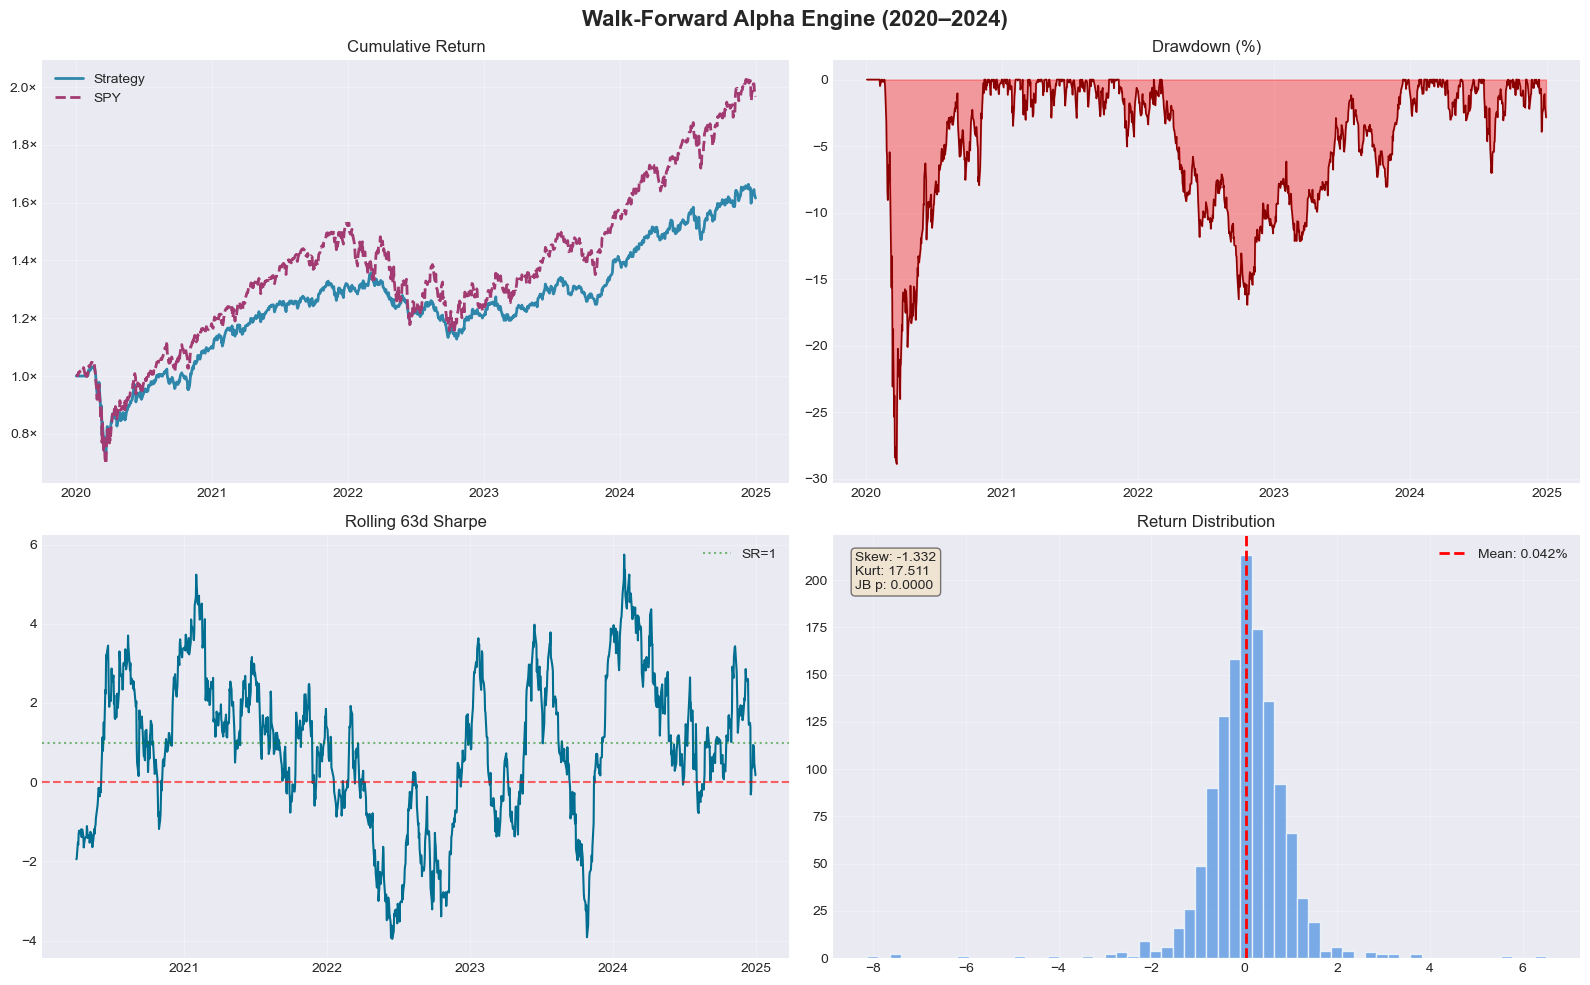

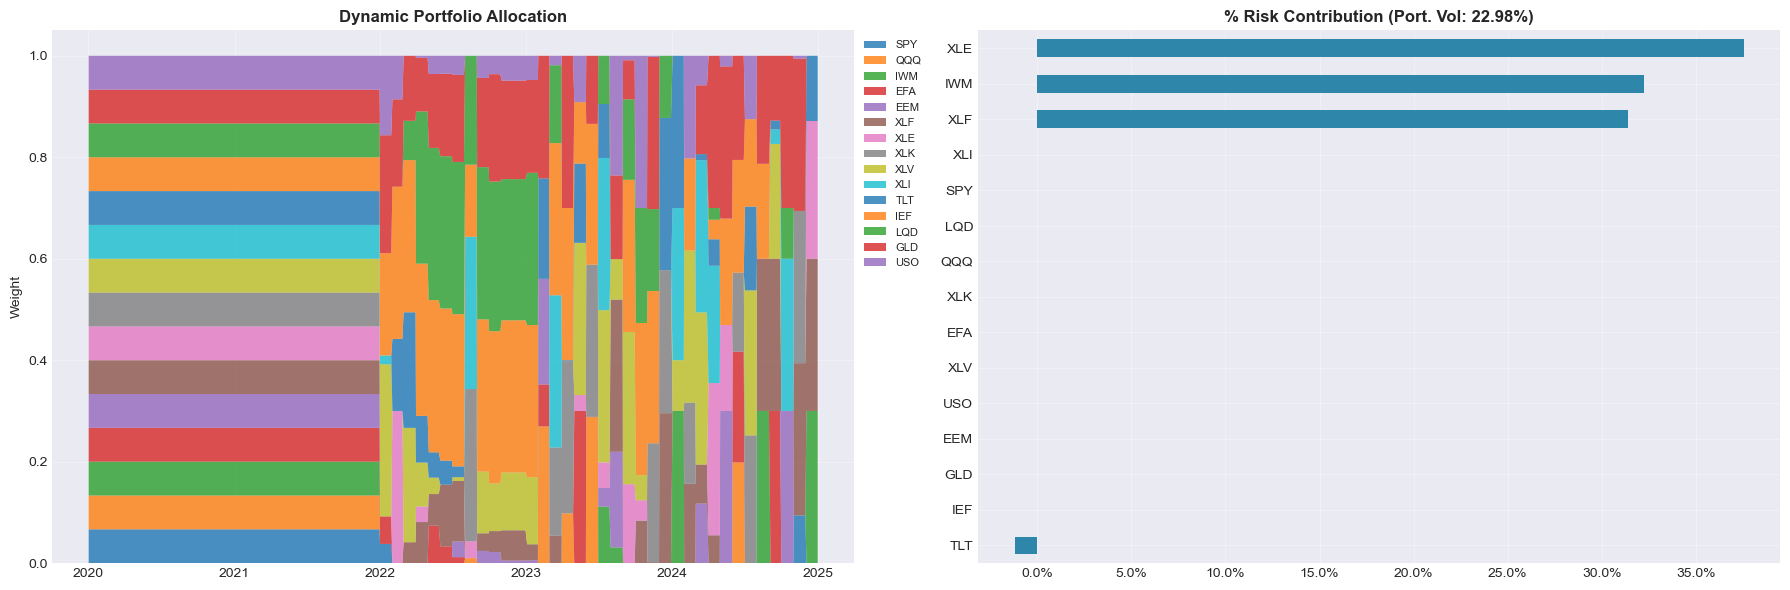

In [19]:
bt      = results["backtester"]
ph      = bt.portfolio_history
prices  = results["prices"]
tickers = results["common_tickers"]
wh      = results["weights_history"]

# 4-panel performance summary
plot_performance(ph, results["spy_returns"], "Walk-Forward Alpha Engine (2020–2024)")

# Weight evolution + risk decomposition
plot_weights_and_risk(
    wh[tickers],
    prices[tickers].pct_change().dropna(),
    wh[tickers].iloc[-1]
)